In [1]:
import math
import json
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from typing import List, Dict
# --- Local Modules ---
# Dynamically add `src/` to sys.path (go up two levels)
notebook_dir = Path.cwd()
sys.path.append(str(notebook_dir.parents[1] / "src"))

from nbutils.compile_plot import compile_zne_subplots
from nbutils.zne_plot import plot_zne_result
from nbutils.summarize import summarize_zne_results
from nbutils.export_raw_data_wrapped import export_raw_data_wrapped
from nbutils.riczne import RichardsonZne
from nbutils.lsf_zne_hill import (
    estimate_E_mix,
    fit_gamma,
    fit_hill_noiseless,
    fit_full,
    hill,
    full_model
)
from nbutils.data_loader import load_all_experiments

from nbutils.lsf_zne import *

In [2]:
plt.rcParams.update({
    "font.family": "serif",
    #"font.serif": "Computer Modern Roman",
    "font.size": 10,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "legend.frameon": False,
})

---

### Load experimental data

In [3]:
# ==========================================
# Recursive experiment loader
# ==========================================

def load_all_experiments(data_root):
    """
    Recursively load all experiments under data_root and
    populate a master data_records dictionary.

    Parameters
    ----------
    data_root : str or Path
        Root directory containing experiment folders (e.g. data/)

    Returns
    -------
    data_records : dict
        Master experiment registry
    """
    data_root = Path(data_root)
    data_records = {}

    # Iterate over subdirectories like c0, c0.01, ...
    for exp_dir in sorted(p for p in data_root.iterdir() if p.is_dir()):
        experiment_id = exp_dir.name

        json_files = sorted(exp_dir.rglob("iter_*.json"))
        if not json_files:
            continue  # skip empty folders

        # --------------------------
        # Load and group raw data
        # --------------------------
        raw_groups = {}
        exact_solution = None

        for jf in json_files:
            with open(jf, "r") as f:
                data = json.load(f)

            t_max = data["config"]["ansatz"]["ugate"]["time"]["max"]
            cost = data["output"]["optimized_minimum_cost"][0]

            if exact_solution is None:
                exact_solution = data["output"].get("exact_sol", None)

            raw_groups.setdefault(t_max, []).append(cost)

        # --------------------------
        # Processed arrays
        # --------------------------
        t_vals = np.array(sorted(raw_groups.keys()))
        vqe_means = np.array([np.mean(raw_groups[t]) for t in t_vals])
        vqe_stds = np.array([np.std(raw_groups[t]) for t in t_vals])

        # --------------------------
        # Register experiment
        # --------------------------
        data_records[experiment_id] = {
            "meta": {
                "experiment_id": experiment_id,
                "data_path": str(exp_dir),
                "num_json_files": len(json_files),
                "noise_level": float(experiment_id.replace("c", "")) if experiment_id.startswith("c") else None,
            },

            "raw": {
                "json_files": [str(f) for f in json_files],
                "grouped_costs": raw_groups,
            },

            "processed": {
                "t_max": t_vals,
                "vqe_means": vqe_means,
                "vqe_stds": vqe_stds,
                "exact_solution": exact_solution,
            },

            # Analysis grows later
            "analysis": {
                "lsf": {},
                "notes": [],
            },
        }

    return data_records

In [4]:
data_records = load_all_experiments("data")

In [5]:
# ==========================================
# DATA EXTRACTION
# ==========================================
data_dir = Path("data/c0")
json_files = sorted(data_dir.rglob("iter_*.json"))

raw_groups, exact_sol = {}, None
for f in json_files:
    with open(f, "r") as file:
        data = json.load(file)
        big_t = data["config"]["ansatz"]["ugate"]["time"]["max"]
        cost = data["output"]["optimized_minimum_cost"][0]
        #if exact_sol is None: exact_sol = data["output"]["exact_sol"]
        if big_t not in raw_groups: raw_groups[big_t] = []
        raw_groups[big_t].append(cost)

EXPERIMENTAL_PROCESSED_DATA = [[(np.mean(raw_groups[t]), np.std(raw_groups[t])), t] for t in sorted(raw_groups.keys())]
print(f"Len: {len(EXPERIMENTAL_PROCESSED_DATA)}")
print(f"Extracted data for {EXPERIMENTAL_PROCESSED_DATA} noise levels.")

Len: 51
Extracted data for [[(3.0000000817631687, 6.991934657836011e-08), 0], [(1.512344102998239, 0.013932395296170701), 1], [(0.34048750489580726, 0.035478751604426574), 2], [(-1.015718826414441, 0.0345301431008247), 3], [(-2.4914599115717384, 0.08496204398301681), 4], [(-3.295158795505818, 0.2343733313117736), 5], [(-4.062004110615584, 0.15865549389626196), 6], [(-4.710940886686118, 0.21010772943622058), 7], [(-4.848972203941356, 0.19079480233245977), 8], [(-5.124314668335285, 0.1621580343826099), 9], [(-5.36806750137307, 0.19087855942686316), 10], [(-5.530711658622038, 0.16442349747081578), 11], [(-5.68977426806609, 0.16536366548814804), 12], [(-5.724989888801153, 0.1599278825799889), 13], [(-5.797664146300366, 0.12925006513377796), 14], [(-5.8500918167345475, 0.11648195027346925), 15], [(-5.817524418404128, 0.1475214842575809), 16], [(-5.904683436616966, 0.07204586425527805), 17], [(-5.9298316312568415, 0.07567479045998024), 18], [(-5.910673807120366, 0.10301714506773366), 19], [(

In [6]:
#LSF_WINDOWS = [(10, 40), (10, 50), (10, 60), (10, 70), (10, 80), (10, 90), (10, 100)]
LSF_WINDOWS = [(0, 30), (0,40), (0, 50)]
EXACT_SOLUTION = -6.026674183332271
print("EXACT_SOLUTION =", EXACT_SOLUTION)

EXACT_SOLUTION = -6.026674183332271


In [7]:
# Extracting components
vqe_means_c0 = data_records["c0"]["processed"]["vqe_means"]
vqe_stds_c0 = data_records["c0"]["processed"]["vqe_stds"]
noise_levels_c0 = data_records["c0"]["processed"]["t_max"]

print(f"Loaded {len(noise_levels_c0)} data points.")
print("EXACT_SOLUTION =", EXACT_SOLUTION)

Loaded 51 data points.
EXACT_SOLUTION = -6.026674183332271


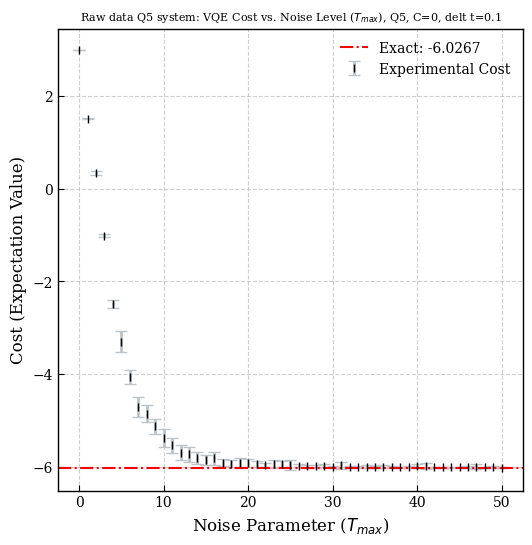

In [8]:
# Create a single clear plot
plt.figure(figsize=(6, 6))
plt.errorbar(noise_levels_c0, vqe_means_c0, yerr=vqe_stds_c0, fmt='|', color='black', 
             ecolor='#bdc3c7', elinewidth=2, capsize=4, markersize=6, 
             label='Experimental Cost')

plt.axhline(y=EXACT_SOLUTION, color='red', linestyle='-.', label=f'Exact: {EXACT_SOLUTION:.4f}')
# Aesthetic improvements
plt.title("Raw data Q5 system: VQE Cost vs. Noise Level ($T_{max}$), Q5, C=0, delt t=0.1", fontsize=8)
plt.xlabel("Noise Parameter ($T_{max}$)", fontsize=12)
plt.ylabel("Cost (Expectation Value)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Save the plot (if in a script) or show (if in a notebook)
#plt.savefig('raw_data_trend.png')
plt.show()

---

In [9]:
"""
Extract experimental data.

Definitions:
    t        → T_max (noise scaling parameter)
    y        → measured energy
    sigma    → standard deviation (optional)
"""

t = noise_levels_c0          # T_max
y = vqe_means_c0
STD_WT = 0.01
sigma = STD_WT + vqe_stds_c0

print(f"Loaded {len(t)} data points")
print(f"T_max range: [{t.min()}, {t.max()}]")

Loaded 51 data points
T_max range: [0, 50]


In [10]:
"""
Fixed Hill exponents to test.
"""

n_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Initial guess for fitted parameters:
#   p0[0] = ZNE → zero-noise extrapolated energy
#   p0[1] = A0  → amplitude = f(0) - ZNE (must be positive)
#   p0[2] = T0  → characteristic noise scale
#   p0 = [ZNE_guess, A0_guess, T0_guess]
p0 = [-5.0, 10.0, 30.0]

bounds = (
    [-10.0, 0.0, 10.0],
    [-1.0, 20.0, 50.0],
)

In [11]:
"""
Store *all* fitting results for later comparison.

Structure:
    results[n] = {
        "params": {ZNE, A, T0},
        "cov": covariance matrix,
        "y_fit": fitted curve,
        "residuals": data - fit,
        "chi2": chi-square,
        "chi2_red": reduced chi-square
    }
"""

fit_results = {}

In [12]:
for n in n_values:

    popt, pcov = fit_hill_noiseless(
        t=t,
        y=y,
        sigma=sigma,
        n=n,
        p0=p0,
        bounds=bounds,
        xtol=1e-10,
        ftol=1e-10,
        gtol=1e-10,
        max_nfev=5000,
    )

    ZNE, A0, T0 = popt

    y_fit = hill(t=t, ZNE=ZNE, A=A0, T0=T0, n=n)
    residuals = y - y_fit

    LS = np.sum((residuals / sigma) ** 2)
    dof = len(y) - 3
    LS_red = LS / dof

    fit_results[n] = {
        "initial_guess": {
            "ZNE0": p0[0],
            "A0_0": p0[1],
            "T0_0": p0[2],
        },
        "params": {
            "ZNE": ZNE,
            "A0": A0,
            "T0": T0,
        },
        "cov": pcov,
        "y_fit": y_fit,
        "residuals": residuals,
        "LS": LS,
        "LS_red": LS_red,
        "dof": dof,
    }


In [13]:
"""
Summary table for noiseless Hill fitting.

Columns:
    ZNE_init, A0_init, T0_init → initial guesses (p0)
    ZNE_fit,  A0_fit,  T0_fit  → fitted parameters
    LS_red                  → reduced chi-square
"""

print(
    f"{'n':>2} | "
    f"{'ZNE_init':>9} | {'A0_init':>9} | {'T0_init':>8} || "
    f"{'ZNE_fit':>9} | {'A0_fit':>9} | {'T0_fit':>8} | "
    f"{'LS':>8}"
)
print("-" * 96)

for n, res in fit_results.items():
    ig = res["initial_guess"]
    p  = res["params"]

    print(
        f"{n:2d} | "
        f"{ig['ZNE0']:9.3f} | "
        f"{ig['A0_0']:9.3f} | "
        f"{ig['T0_0']:8.2f} || "
        f"{p['ZNE']:9.4f} | "
        f"{p['A0']:9.4f} | "
        f"{p['T0']:8.2f} | "
        f"{res['LS']:8.3f}"
    )

 n |  ZNE_init |   A0_init |  T0_init ||   ZNE_fit |    A0_fit |   T0_fit |       LS
------------------------------------------------------------------------------------------------
 1 |    -5.000 |    10.000 |    30.00 ||   -8.3363 |   11.1214 |    10.00 | 9291.696
 2 |    -5.000 |    10.000 |    30.00 ||   -6.6517 |    9.1598 |    10.00 | 17300.049
 3 |    -5.000 |    10.000 |    30.00 ||   -6.2117 |    8.6702 |    10.00 | 19066.577
 4 |    -5.000 |    10.000 |    30.00 ||   -6.0816 |    8.5269 |    10.00 | 19689.406
 5 |    -5.000 |    10.000 |    30.00 ||   -6.0383 |    8.4781 |    10.00 | 20053.469
 6 |    -5.000 |    10.000 |    30.00 ||   -6.0217 |    8.4583 |    10.00 | 20316.162
 7 |    -5.000 |    10.000 |    30.00 ||   -6.0143 |    8.4487 |    10.00 | 20524.295
 8 |    -5.000 |    10.000 |    30.00 ||   -6.0104 |    8.4430 |    10.00 | 20697.100
 9 |    -5.000 |    10.000 |    30.00 ||   -6.0080 |    8.4392 |    10.00 | 20844.366
10 |    -5.000 |    10.000 |    30.00 ||   -6

---

### $T_{max}$ range [0, 30]

In [14]:
"""
Extract experimental data.

Definitions:
    t        → T_max (noise scaling parameter)
    y        → measured energy
    sigma    → standard deviation (optional)
"""

t = noise_levels_c0[:30]          # T_max
y = vqe_means_c0[:30]
std_wt = 0.01
sigma = std_wt + vqe_stds_c0[:30]

print(f"Loaded {len(t)} data points")
print(f"T_max range: [{t.min()}, {t.max()}]")

"""
Fixed Hill exponents to test.
"""

n_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Initial guess for fitted parameters:
#   p0[0] = ZNE → zero-noise extrapolated energy
#   p0[1] = A0  → amplitude = f(0) - ZNE (must be positive)
#   p0[2] = T0  → characteristic noise scale
#   p0 = [ZNE_guess, A0_guess, T0_guess]
p0 = [-5.0, 10.0, 30.0]

bounds = (
    [-10.0, 0.0, 10.0],
    [-1.0, 20.0, 50.0],
)


Loaded 30 data points
T_max range: [0, 29]


In [15]:
for n in n_values:

    popt, pcov = fit_hill_noiseless(
        t=t,
        y=y,
        sigma=sigma,
        n=n,
        p0=p0,
        bounds=bounds,
        xtol=1e-10,
        ftol=1e-10,
        gtol=1e-10,
        max_nfev=5000,
    )

    ZNE, A0, T0 = popt

    y_fit = hill(t=t, ZNE=ZNE, A=A0, T0=T0, n=n)
    residuals = y - y_fit

    LS = np.sum((residuals / sigma) ** 2)
    dof = len(y) - 3
    LS_red = LS / dof

    fit_results[n] = {
        "initial_guess": {
            "ZNE0": p0[0],
            "A0_0": p0[1],
            "T0_0": p0[2],
        },
        "params": {
            "ZNE": ZNE,
            "A0": A0,
            "T0": T0,
        },
        "cov": pcov,
        "y_fit": y_fit,
        "residuals": residuals,
        "LS": LS,
        "LS_red": LS_red,
        "dof": dof,
    }


In [16]:
"""
Summary table for noiseless Hill fitting.

Columns:
    ZNE_init, A0_init, T0_init → initial guesses (p0)
    ZNE_fit,  A0_fit,  T0_fit  → fitted parameters
    LS_red                  → reduced chi-square
"""
print(f"T_max range [0, 30]: {t}")
print(
    f"{'n':>2} | "
    f"{'ZNE_init':>9} | {'A0_init':>9} | {'T0_init':>8} || "
    f"{'ZNE_fit':>9} | {'A0_fit':>9} | {'T0_fit':>8} | "
    f"{'LS':>8}"
)
print("-" * 96)

for n, res in fit_results.items():
    ig = res["initial_guess"]
    p  = res["params"]
    
    print(
        f"{n:2d} | "
        f"{ig['ZNE0']:9.3f} | "
        f"{ig['A0_0']:9.3f} | "
        f"{ig['T0_0']:8.2f} || "
        f"{p['ZNE']:9.4f} | "
        f"{p['A0']:9.4f} | "
        f"{p['T0']:8.2f} | "
        f"{res['LS']:8.3f}"
    )

T_max range [0, 30]: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]
 n |  ZNE_init |   A0_init |  T0_init ||   ZNE_fit |    A0_fit |   T0_fit |       LS
------------------------------------------------------------------------------------------------
 1 |    -5.000 |    10.000 |    30.00 ||   -9.8628 |   12.7456 |    10.00 | 2877.586
 2 |    -5.000 |    10.000 |    30.00 ||   -7.6584 |   10.2061 |    10.00 | 13745.276
 3 |    -5.000 |    10.000 |    30.00 ||   -6.7601 |    9.2310 |    10.00 | 17909.370
 4 |    -5.000 |    10.000 |    30.00 ||   -6.3824 |    8.8317 |    10.00 | 19329.262
 5 |    -5.000 |    10.000 |    30.00 ||   -6.2100 |    8.6513 |    10.00 | 19932.931
 6 |    -5.000 |    10.000 |    30.00 ||   -6.1244 |    8.5616 |    10.00 | 20271.354
 7 |    -5.000 |    10.000 |    30.00 ||   -6.0780 |    8.5126 |    10.00 | 20505.756
 8 |    -5.000 |    10.000 |    30.00 ||   -6.0505 |    8.4833 |    10.00 | 20688.575
 9 |    -5.000 | 

---

In [17]:
"""
Extract experimental data.

Definitions:
    t        → T_max (noise scaling parameter)
    y        → measured energy
    sigma    → standard deviation (optional)
"""

t = noise_levels_c0[:30]          # T_max
y = vqe_means_c0[:30]
std_wt = 0.01
sigma = std_wt + vqe_stds_c0[:30]

"""
Fixed Hill exponents to test.
"""

n_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Initial guess for fitted parameters:
#   p0[0] = ZNE → zero-noise extrapolated energy
#   p0[1] = A0  → amplitude = f(0) - ZNE (must be positive)
#   p0[2] = T0  → characteristic noise scale
#   p0 = [ZNE_guess, A0_guess, T0_guess]
p0 = [-5.0, 10.0, 8]

bounds = (
    [-10.0, 0.0, 0],
    [-1.0, 20.0, 50.0],
)

for n in n_values:

    popt, pcov = fit_hill_noiseless(
        t=t,
        y=y,
        sigma=sigma,
        n=n,
        p0=p0,
        bounds=bounds,
        xtol=1e-10,
        ftol=1e-10,
        gtol=1e-10,
        max_nfev=5000,
    )

    ZNE, A0, T0 = popt

    y_fit = hill(t=t, ZNE=ZNE, A=A0, T0=T0, n=n)
    residuals = y - y_fit

    LS = np.sum((residuals / sigma) ** 2)
    dof = len(y) - 3
    LS_red = LS / dof

    fit_results[n] = {
        "initial_guess": {
            "ZNE0": p0[0],
            "A0_0": p0[1],
            "T0_0": p0[2],
        },
        "params": {
            "ZNE": ZNE,
            "A0": A0,
            "T0": T0,
        },
        "cov": pcov,
        "y_fit": y_fit,
        "residuals": residuals,
        "LS": LS,
        "LS_red": LS_red,
        "dof": dof,
    }
"""
Summary table for noiseless Hill fitting.

Columns:
    ZNE_init, A0_init, T0_init → initial guesses (p0)
    ZNE_fit,  A0_fit,  T0_fit  → fitted parameters
    LS_red                  → reduced chi-square
"""
print(f"T_max range [0, 30]: {t}\n\n")
print(
    f"{'n':>2} | "
    f"{'ZNE_init':>9} | {'A0_init':>9} | {'T0_init':>8} || "
    f"{'ZNE_fit':>9} | {'A0_fit':>9} | {'T0_fit':>8} | "
    f"{'LS':>8}"
)
print("-" * 96)

for n, res in fit_results.items():
    ig = res["initial_guess"]
    p  = res["params"]
    
    print(
        f"{n:2d} | "
        f"{ig['ZNE0']:9.3f} | "
        f"{ig['A0_0']:9.3f} | "
        f"{ig['T0_0']:8.2f} || "
        f"{p['ZNE']:9.4f} | "
        f"{p['A0']:9.4f} | "
        f"{p['T0']:8.2f} | "
        f"{res['LS']:8.3f}"
    )

T_max range [0, 30]: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]


 n |  ZNE_init |   A0_init |  T0_init ||   ZNE_fit |    A0_fit |   T0_fit |       LS
------------------------------------------------------------------------------------------------
 1 |    -5.000 |    10.000 |     8.00 ||   -7.9469 |   10.9786 |     5.20 |  862.552
 2 |    -5.000 |    10.000 |     8.00 ||   -6.0887 |    9.0217 |     3.04 |  709.796
 3 |    -5.000 |    10.000 |     8.00 ||   -5.9194 |    8.7522 |     2.98 | 2475.397
 4 |    -5.000 |    10.000 |     8.00 ||   -5.8848 |    8.6586 |     3.03 | 3855.062
 5 |    -5.000 |    10.000 |     8.00 ||   -5.8700 |    8.6109 |     3.06 | 4817.718
 6 |    -5.000 |    10.000 |     8.00 ||   -5.8606 |    8.5808 |     3.08 | 5527.613
 7 |    -5.000 |    10.000 |     8.00 ||   -5.8525 |    8.5591 |     3.10 | 6061.326
 8 |    -5.000 |    10.000 |     8.00 ||   -5.8446 |    8.5424 |     3.10 | 6463.625
 9 |    -5.000 |    10

---

In [18]:
BEST_n  = 2
BEST_T0 = 3.04
BEST_A0 = 9.0217
ZNE_c0_best = -6.0887
E_mix   = 0.0   # Tr(H_Ising) = 0

data_records["c0"]["analysis"]["lsf"]["best_noiseless"] = {
    "model": "ZNE + A/(1+(t/T0)^n)",
    "optimized": {
        "n": BEST_n,
        "A": BEST_A0,
        "T0": BEST_T0,
    }
}

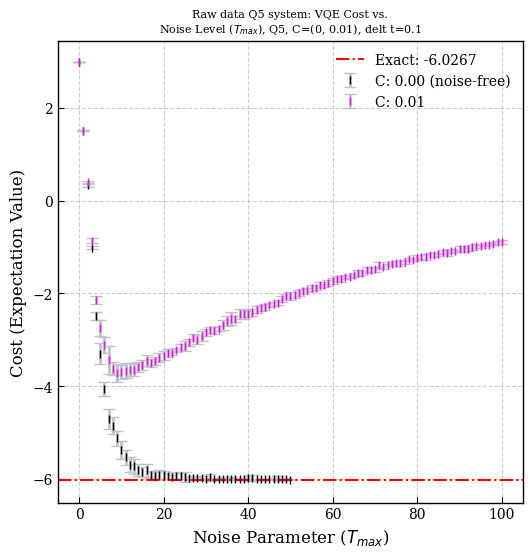

In [19]:
# Extracting components
vqe_means_c0_01 = data_records["c0.01"]["processed"]["vqe_means"]
vqe_stds_c0_01 = data_records["c0.01"]["processed"]["vqe_stds"]
noise_levels_c0_01 = data_records["c0.01"]["processed"]["t_max"]
# Create a single clear plot
plt.figure(figsize=(6, 6))
plt.errorbar(noise_levels_c0, vqe_means_c0, yerr=vqe_stds_c0, fmt='|', color='black', 
             ecolor='#bdc3c7', elinewidth=2, capsize=4, markersize=6, 
             label='C: 0.00 (noise-free)')
plt.errorbar(noise_levels_c0_01, vqe_means_c0_01, yerr=vqe_stds_c0_01, fmt='|', color='magenta', 
             ecolor='#bdc3c7', elinewidth=2, capsize=4, markersize=6, 
             label='C: 0.01')
plt.axhline(y=EXACT_SOLUTION, color='red', linestyle='-.', label=f'Exact: {EXACT_SOLUTION:.4f}')
# Aesthetic improvements
plt.title("Raw data Q5 system: VQE Cost vs.\nNoise Level ($T_{max}$), Q5, C=(0, 0.01), delt t=0.1", fontsize=8)
plt.xlabel("Noise Parameter ($T_{max}$)", fontsize=12)
plt.ylabel("Cost (Expectation Value)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Save the plot (if in a script) or show (if in a notebook)
# plt.savefig('raw_data_trend.png')
plt.show()

In [20]:
rec = data_records["c0.01"]

t = rec["processed"]["t_max"][-30:]
y = rec["processed"]["vqe_means"][-30:]
sigma = rec["processed"]["vqe_stds"][-30:]

bounds = (
    [-10.0, 0.0, 0],
    [-1.0, 20.0, 50.0],
)

In [23]:
# --- FIX: make p0 feasible ---
eps = 1e-12

gamma_guess = -np.log(max(abs(y[-1] / y[0]), eps)) / (t[-1] - t[0])
gamma_guess = np.clip(gamma_guess, 1e-6, 1.0)

C_guess = y[0] * np.exp(gamma_guess * t[0])
C_guess = max(C_guess, 0.0)

p0 = [
    C_guess,        # amplitude C
    gamma_guess     # decay rate γ
]

bounds = (
    [0.0, 1e-6],    # C ≥ 0, γ > 0
    [np.inf, 1.0],  # γ typically < 1 for your scale
)

ftol = 1e-12
xtol = 1e-12
gtol = 1e-12

popt_gamma, pcov_gamma = fit_gamma(
    t=t,
    y=y,
    sigma=sigma,
    E_mix=E_mix,
    p0=p0,
    bounds=bounds,
    ftol=ftol,
    xtol=xtol,
    gtol=gtol,
)

C_hat, gamma_hat = popt_gamma

print("=== Large-T exponential tail fit ===")
print(f"C     = {C_hat:.6f}")
print(f"gamma = {gamma_hat:.6e}")
print(f"gamma * t_max ≈ {gamma_hat * np.max(t):.3f}")


=== Large-T exponential tail fit ===
C     = 0.000000
gamma = 3.137917e-02
gamma * t_max ≈ 3.138
